# SILVA Poisson Mirror Equilibrium

This lab derives the Poisson data term, the Burg mirror map, its closed-form
positive update, and the fixed-point reconstruction. It verifies a seeded
Poisson imaging problem and compares data fidelity before and after the
equilibrium. The mechanism follows DEQ-MD [50] inside SILVA.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [50](https://jseluis.github.io/silva-networks/paper/references/#ref-50). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVABurgMirrorTransition,
    SILVAPoissonMirrorEquilibrium,
    SolverConfig,
    make_poisson_inverse_dataset,
    poisson_kl,
)

torch.manual_seed(230)

## 1. Poisson Observation Model

For nonnegative image $x$ and forward operator $A$,

$$
y_i\sim\operatorname{Poisson}((Ax)_i).
$$

Ignoring terms independent of $x$, the data fidelity is the generalized KL
divergence

$$
D_{\mathrm{KL}}(y,Ax)
=\sum_i y_i\log\frac{y_i}{(Ax)_i}+(Ax)_i-y_i.
$$

Its gradient is

$$
\nabla_xD_{\mathrm{KL}}=A^T\left(1-\frac{y}{Ax}\right).
$$

In [3]:
data = make_poisson_inverse_dataset(samples=3, height=8, width=8, exposure=30, seed=23)
assert data.expected_equation_residual().abs().max() == 0
assert data.clean.min() > 0 and data.observation.min() >= 0
print("clean/observed:", tuple(data.clean.shape), tuple(data.observation.shape))
print("clean-image KL:", float(data.data_fidelity(data.clean)))

clean/observed: (3, 1, 8, 8) (3, 1, 8, 8)
clean-image KL: 0.016562730073928833


## 2. Why Euclidean Descent Is Not the Same Update

Ordinary gradient descent adds a vector in Euclidean coordinates. Burg entropy

$$
h(x)=-\sum_i\log x_i,
\qquad \nabla h(x)=-x^{-1},
$$

defines geometry on the positive orthant. A mirror step with learned
regularizer gradient $r_\theta(x)$ is

$$
x^+=\nabla h^*\left(
\nabla h(x)-\tau[\nabla D_{\mathrm{KL}}+r_\theta(x)]
\right).
$$

## 3. Closed-Form Burg Update

Substituting $\nabla h(x)=-1/x$ gives

$$
x^+
=\frac{x}{1+\tau x\odot
\left[A^T\left(1-\frac{y}{Ax}\right)+r_\theta(x)\right]}.
$$

`SILVABurgMirrorTransition` applies this expression and a positive box
projection. The denominator floor is a numerical safeguard for compact runs;
full experiments should report any line search or backtracking policy.

In [4]:
transition = SILVABurgMirrorTransition(
    forward_operator=data.forward_operator,
    adjoint_operator=data.adjoint_operator,
    step_size=0.05,
    minimum=1e-4,
    maximum=3.0,
)
initial = data.observation.clamp_min(1e-4)
one_step = transition(initial, data.observation)
assert one_step.min() > 0
print("KL before/after one mirror step:",
      float(poisson_kl(data.observation, data.forward_operator(initial))),
      float(poisson_kl(data.observation, data.forward_operator(one_step))))

KL before/after one mirror step: 0.005836570169776678 0.005766694899648428


## 4. Mirror Step as a SILVA Equilibrium

The source is the observed count field $y$. The local/global field is the
forward-adjoint physics pair $A,A^T$. The self branch is the optional learned
regularizer gradient. Reusing the mirror transition gives

$$
x^\star=T_{\mathrm{Burg}}(x^\star;y).
$$

At a positive interior fixed point, the combined data and regularizer gradient
vanishes.

In [5]:
model = SILVAPoissonMirrorEquilibrium(
    transition=transition,
    config=SolverConfig(
        solver="picard",
        max_iter=20,
        tol=1e-6,
        anderson_batch_dims=1,
    ),
)
result = model(data.observation, z0=initial, return_result=True)
final_kl = poisson_kl(data.observation, result.intensity)
assert result.output.min() > 0
print("equilibrium residual:", result.solver_result.residual)
print("final KL:", float(final_kl))

equilibrium residual: 0.012612477876245975
final KL: 0.004821363836526871


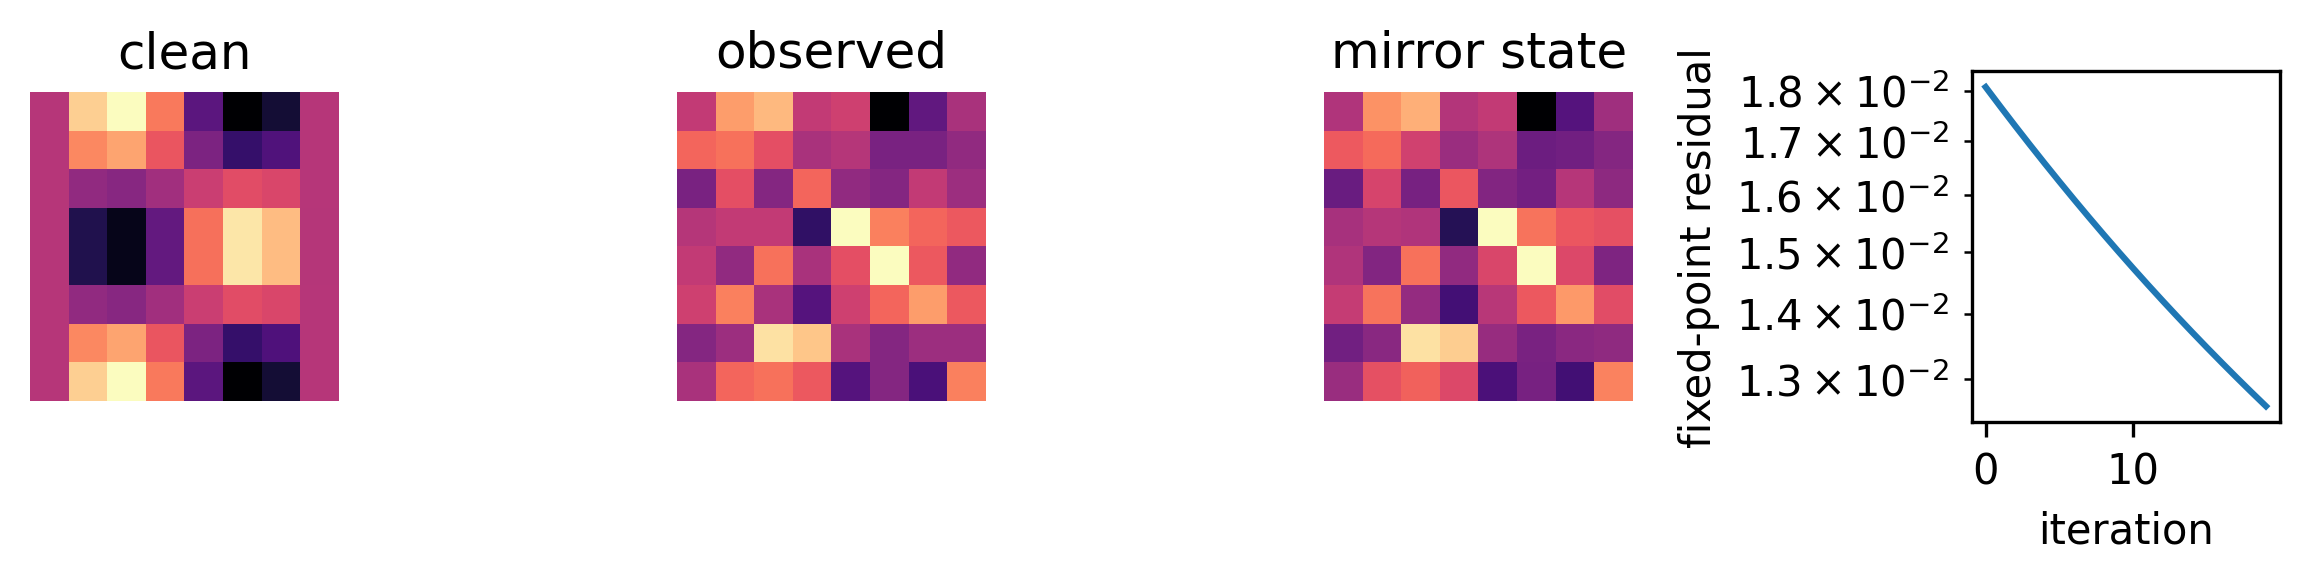

In [6]:
figure, axes = plt.subplots(1, 4, figsize=(7.8, 2.0))
axes[0].imshow(data.clean[0, 0], cmap="magma")
axes[0].set_title("clean")
axes[1].imshow(data.observation[0, 0], cmap="magma")
axes[1].set_title("observed")
axes[2].imshow(result.output.detach()[0, 0], cmap="magma")
axes[2].set_title("mirror state")
axes[3].semilogy(result.solver_result.residuals)
axes[3].set(xlabel="iteration", ylabel="fixed-point residual")
for axis in axes[:3]:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 5. Learned Regularizer Contract

`regularizer_gradient` must preserve the image shape and return a gradient-like
field. A convolutional network, U-Net, or another SILVA point architecture can
occupy this branch. If the module is intended to be the gradient of a scalar
regularizer, that integrability claim requires a separate check; shape
preservation alone does not prove it.

## 6. Reproduction Checklist

Report the sensing operator and adjoint test, count scaling, exposure, box
bounds, mirror step, denominator or line-search safeguard, equilibrium solver,
residual, reconstruction metric, and learned regularizer architecture. This
small dataset validates the implementation path; it is not a medical or
astronomical benchmark.

## Where to Go Next

| Question | Page |
| --- | --- |
| How is the Burg update derived? | [Advanced Equilibrium Families](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-families/#poisson-mirror-equilibrium) |
| How are the seeded Poisson observations generated? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#poisson-inverse-images) |
| Which mirror and KL objects are public? | [Physics-Informed API](https://jseluis.github.io/silva-networks/api/physics_informed/) |
